In [1]:
!pip install sentence-transformers hdbscan umap-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 671.8/671.8 kB 5.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.0 MB 11.2 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 11.8 MB/s  0:00:00

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.4.2

   ---------------------------------------- 0/2 [scikit-learn]
    Uninstalling scikit-learn-1.4.2:
   ---------------------------------------- 0/2 [scikit-learn]
      Successfully uninstalled scikit-learn-1.4.2
   --------------------------

In [1]:
import json

path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

paper_ids = list(data.keys())
texts = [data[pid]["content"] for pid in paper_ids]

print("Total papers:", len(texts))

Total papers: 8253


In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Batches:   0%|          | 0/129 [00:00<?, ?it/s]

Embedding shape: (8253, 384)


In [ ]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,     # tune
    metric='euclidean',      # cosine cũng OK nếu normalize
    cluster_selection_method='eom'
)

In [ ]:
import hdbscan



labels = clusterer.fit_predict(embeddings)

print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))
import pandas as pd

df = pd.DataFrame({
    "paper_id": paper_ids,
    "text": texts,
    "cluster": labels
})

import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

emb_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    s=5
)

plt.title("HDBSCAN Clusters (UMAP projection)")
plt.colorbar(scatter)
plt.show()

Number of clusters: 5
Noise points: 4669


In [5]:
from sklearn.metrics import silhouette_score

# bỏ noise
mask = labels != -1

score = silhouette_score(
    embeddings[mask],
    labels[mask],
    metric='cosine'
)

print("Silhouette:", score)

Silhouette: 0.11277010291814804


Total papers: 8253


Batches:   0%|          | 0/129 [00:00<?, ?it/s]


=== GRID SEARCH RESULTS ===


,min_cluster_size,min_samples,silhouette,noise,clusters
4,15,5,0.289109,0.910820,21
1,5,3,0.270416,0.837514,118
3,10,3,0.256683,0.863686,51
2,10,1,0.211008,0.802860,72
0,5,1,0.200994,0.726281,229
5,20,5,0.091509,0.436447,2



=== BEST CONFIG ===
min_cluster_size    15.000000
min_samples          5.000000
silhouette           0.289109
noise                0.910820
clusters            21.000000
Name: 4, dtype: float64

Cluster distribution:
cluster
-1     7517
 20      99
 5       89
 11      74
 2       51
 17      42
 0       41
 8       37
 19      32
 10      32
Name: count, dtype: int64


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


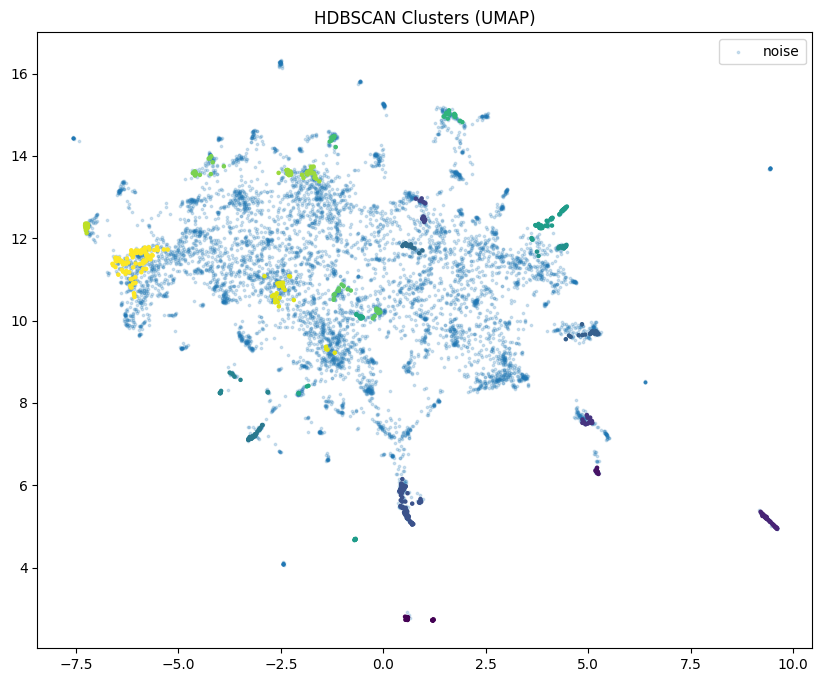


=== SAMPLE CLUSTERS ===

--- Cluster 0 ---
- Title: Referring Expressions Again. Keywords: applied linguistics, computer science, linguistics, paraphrase, language, general linguistics, syntax, c
- Title: A computational model of referring. Keywords: linguistics, semantics, computational semantics, language model, reference model, computational l
- Title: Generating referring expressions in a domain of objects and processes (language representation). Keywords: word embeddings, computer science, l

--- Cluster 1 ---
- Title: BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. Keywords: computer science, language model, natural language 
- Title: BERTje: A Dutch BERT Model. Keywords: dutch bert model, text mining, knowledge representation and reasoning, reference model, language model, m
- Title: AlBERTo: Italian BERT Language Understanding Model for NLP Challenging Tasks Based on Tweets.. Keywords: computer science, natural language int

--- Cluster 2 ---


In [6]:
# ===== ALL-IN-ONE PIPELINE =====

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

import hdbscan
import umap

# ---------- 1. LOAD DATA ----------
path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

paper_ids = list(data.keys())

texts = [
    f"Title: {data[pid]['title']}. Keywords: {', '.join(data[pid]['keywords'])}"
    for pid in paper_ids
]

print("Total papers:", len(texts))


# ---------- 2. EMBEDDING ----------
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# normalize for cosine
embeddings = normalize(embeddings)


# ---------- 3. EVALUATION FUNCTION ----------
def evaluate(labels, embeddings):
    mask = labels != -1
    
    if len(set(labels[mask])) < 2:
        return None
    
    sil = silhouette_score(embeddings[mask], labels[mask], metric='euclidean')
    noise_ratio = (labels == -1).sum() / len(labels)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    return {
        "silhouette": sil,
        "noise": noise_ratio,
        "clusters": num_clusters
    }


# ---------- 4. GRID SEARCH ----------
param_grid = [
    (5, 1),
    (5, 3),
    (10, 1),
    (10, 3),
    (15, 5),
    (20, 5),
]

results = []

for min_cluster_size, min_samples in param_grid:
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom'
    )
    
    labels = clusterer.fit_predict(embeddings)
    metrics = evaluate(labels, embeddings)
    
    if metrics:
        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            **metrics
        })

df_results = pd.DataFrame(results).sort_values("silhouette", ascending=False)

print("\n=== GRID SEARCH RESULTS ===")
display(df_results)


# ---------- 5. PICK BEST CONFIG ----------
best = df_results.iloc[0]

print("\n=== BEST CONFIG ===")
print(best)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=int(best.min_cluster_size),
    min_samples=int(best.min_samples),
    metric='euclidean',
    cluster_selection_method='eom'
)

labels = clusterer.fit_predict(embeddings)


# ---------- 6. BUILD DF ----------
df = pd.DataFrame({
    "paper_id": paper_ids,
    "text": texts,
    "cluster": labels,
    "year": [data[pid]["pub_year"] for pid in paper_ids]
})

print("\nCluster distribution:")
print(df["cluster"].value_counts().head(10))


# ---------- 7. UMAP VISUALIZATION ----------
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

emb_2d = reducer.fit_transform(embeddings)

mask = labels != -1

plt.figure(figsize=(10, 8))

# noise (nhạt)
plt.scatter(
    emb_2d[~mask, 0],
    emb_2d[~mask, 1],
    s=3,
    alpha=0.2,
    label="noise"
)

# clusters
plt.scatter(
    emb_2d[mask, 0],
    emb_2d[mask, 1],
    c=labels[mask],
    s=5
)

plt.title("HDBSCAN Clusters (UMAP)")
plt.legend()
plt.show()


# ---------- 8. SAMPLE CLUSTERS ----------
print("\n=== SAMPLE CLUSTERS ===")

for c in sorted(df["cluster"].unique()):
    if c == -1:
        continue
    
    print(f"\n--- Cluster {c} ---")
    samples = df[df["cluster"] == c].head(3)
    
    for t in samples["text"]:
        print("-", t[:150])

# BerTopic

In [2]:
# ==== ONE-CELL BERTopic PIPELINE WITH HYPERPARAM SEARCH & EVALUATION ====

# Install if needed:
# !pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn

import numpy as np
from copy import deepcopy
from itertools import product
from collections import defaultdict

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
import hdbscan

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import json

path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert về list documents đúng format
documents = []
for paper_id, paper in data.items():
    content = paper.get("content", "")
    
    # fallback nếu content rỗng
    if not content:
        title = paper.get("title", "")
        keywords = " ".join(paper.get("keywords", []))
        content = f"{title}. {keywords}"
    
    documents.append({
        "id": paper_id,
        "content": content,
        "year": paper.get("pub_year"),
        "citations": paper.get("cited_by_count", 0)
    })

print("Loaded docs:", len(documents))
texts = [d["content"] for d in documents if d.get("content")]

assert len(texts) > 10, "Need enough documents for clustering (~>20 recommended)."


# =========================
# 2. EMBEDDINGS
# =========================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(texts, show_progress_bar=True)


# =========================
# 3. PARAM GRID
# =========================
param_grid = {
    "n_neighbors": [10, 15],
    "n_components": [5, 10],
    "min_cluster_size": [5, 10, 20],
    "min_samples": [None, 5]
}


# =========================
# 4. EVALUATION FUNCTION
# =========================
def evaluate_clustering(embeddings, labels):
    # remove outliers (-1)
    mask = labels != -1
    filtered_embeddings = embeddings[mask]
    filtered_labels = labels[mask]

    # need at least 2 clusters
    if len(set(filtered_labels)) < 2:
        return {
            "silhouette": -1,
            "db": np.inf,
            "ch": -1,
            "valid_points": len(filtered_labels)
        }

    try:
        sil = silhouette_score(filtered_embeddings, filtered_labels)
        db = davies_bouldin_score(filtered_embeddings, filtered_labels)
        ch = calinski_harabasz_score(filtered_embeddings, filtered_labels)
    except:
        sil, db, ch = -1, np.inf, -1

    return {
        "silhouette": sil,
        "db": db,
        "ch": ch,
        "valid_points": len(filtered_labels)
    }


# =========================
# 5. GRID SEARCH
# =========================
results = []

for n_neighbors, n_components, min_cluster_size, min_samples in product(
    param_grid["n_neighbors"],
    param_grid["n_components"],
    param_grid["min_cluster_size"],
    param_grid["min_samples"]
):
    try:
        umap_model = UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            metric='cosine',
            random_state=42
        )

        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric='euclidean',
            prediction_data=True
        )

        topic_model = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            calculate_probabilities=True,
            verbose=False
        )

        topics, probs = topic_model.fit_transform(texts)

        labels = np.array(topics)

        metrics = evaluate_clustering(embeddings, labels)

        result = {
            "params": {
                "n_neighbors": n_neighbors,
                "n_components": n_components,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples
            },
            "num_topics": len(set(labels)) - (1 if -1 in labels else 0),
            "outliers": int(np.sum(labels == -1)),
            **metrics
        }

        results.append(result)

        print(f"Done: {result}")

    except Exception as e:
        print(f"Failed config: {e}")


# =========================
# 6. SELECT BEST CONFIG
# =========================
# Strategy: maximize silhouette, minimize DB
def score_fn(r):
    return r["silhouette"] - 0.1 * r["db"]

results_sorted = sorted(results, key=score_fn, reverse=True)

print("\n==== TOP CONFIGS ====")
for r in results_sorted[:5]:
    print(r)


# =========================
# 7. REFIT BEST MODEL
# =========================
best = results_sorted[0]["params"]

print("\nBest params:", best)

umap_model = UMAP(
    n_neighbors=best["n_neighbors"],
    n_components=best["n_components"],
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=best["min_cluster_size"],
    min_samples=best["min_samples"],
    metric='euclidean',
    prediction_data=True
)

final_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

final_topics, final_probs = final_model.fit_transform(texts)


# =========================
# 8. INSPECT TOPICS
# =========================
print("\n==== FINAL TOPICS ====")
for topic_id in set(final_topics):
    if topic_id == -1:
        continue
    print(f"\nTopic {topic_id}:")
    print(final_model.get_topic(topic_id)[:10])


# =========================
# OUTPUTS:
# - final_model
# - final_topics (per doc)
# - final_probs
# =========================

Loaded docs: 8253


Batches:   0%|          | 0/258 [00:00<?, ?it/s]

Done: {'params': {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 5, 'min_samples': None}, 'num_topics': 276, 'outliers': 2787, 'silhouette': 0.0456460602581501, 'db': 2.5167814511762696, 'ch': 15.446561149080003, 'valid_points': 5466}
Done: {'params': {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 5, 'min_samples': 5}, 'num_topics': 276, 'outliers': 2787, 'silhouette': 0.0456460602581501, 'db': 2.5167814511762696, 'ch': 15.446561149080003, 'valid_points': 5466}
Done: {'params': {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 10, 'min_samples': None}, 'num_topics': 130, 'outliers': 2755, 'silhouette': 0.04535491764545441, 'db': 2.652473004447458, 'ch': 25.685544183090283, 'valid_points': 5498}
Done: {'params': {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 10, 'min_samples': 5}, 'num_topics': 171, 'outliers': 2573, 'silhouette': 0.04309877008199692, 'db': 2.7513372467978865, 'ch': 22.095305070011786, 'valid_points': 5680}
Done: {'params': {'

2026-03-27 20:16:01,656 - BERTopic - Embedding - Transforming documents to embeddings.


Done: {'params': {'n_neighbors': 15, 'n_components': 10, 'min_cluster_size': 20, 'min_samples': 5}, 'num_topics': 88, 'outliers': 2903, 'silhouette': 0.050393007695674896, 'db': 2.914809345934337, 'ch': 35.89279291756679, 'valid_points': 5350}

==== TOP CONFIGS ====
{'params': {'n_neighbors': 15, 'n_components': 10, 'min_cluster_size': 5, 'min_samples': None}, 'num_topics': 235, 'outliers': 2874, 'silhouette': 0.04823819920420647, 'db': 2.5151763275747303, 'ch': 17.147755178193396, 'valid_points': 5379}
{'params': {'n_neighbors': 15, 'n_components': 10, 'min_cluster_size': 5, 'min_samples': 5}, 'num_topics': 235, 'outliers': 2874, 'silhouette': 0.04823819920420647, 'db': 2.5151763275747303, 'ch': 17.147755178193396, 'valid_points': 5379}
{'params': {'n_neighbors': 15, 'n_components': 10, 'min_cluster_size': 10, 'min_samples': None}, 'num_topics': 108, 'outliers': 3184, 'silhouette': 0.052847329527139664, 'db': 2.5653695615368455, 'ch': 29.361465669537093, 'valid_points': 5069}
{'params

Batches:   0%|          | 0/258 [00:00<?, ?it/s]

2026-03-27 20:16:11,435 - BERTopic - Embedding - Completed ✓
2026-03-27 20:16:11,435 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-27 20:16:24,300 - BERTopic - Dimensionality - Completed ✓
2026-03-27 20:16:24,301 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-27 20:16:37,901 - BERTopic - Cluster - Completed ✓
2026-03-27 20:16:37,904 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-27 20:16:38,640 - BERTopic - Representation - Completed ✓



==== FINAL TOPICS ====

Topic 0:
[('evaluation', 0.01974411308244749), ('metrics', 0.015481400711561252), ('quality', 0.012798009012325605), ('estimation', 0.012366313933880504), ('human', 0.011186061371856), ('automatic', 0.009963834863200476), ('metric', 0.009842656885090647), ('mt', 0.009481786681556506), ('judgments', 0.008643784509344552), ('output', 0.007908550173810276)]

Topic 1:
[('software', 0.015863701554657588), ('binary', 0.015110449067128058), ('dynamic', 0.013071931002335441), ('engineering', 0.012424712961609765), ('code', 0.010426250502444986), ('program', 0.009856327634430962), ('hardware', 0.009162371631589913), ('compiler', 0.008824293495860657), ('programming', 0.008639213305716908), ('execution', 0.008602362703680142)]

Topic 2:
[('specialized', 0.07079540066771849), ('multimodal', 0.05534843291740358), ('literature', 0.0526644838009994), ('comparative', 0.04285409850825503), ('studies', 0.04169756030398016), ('translation', 0.02545424600574639), ('manga', 0.0165

In [6]:
# ==== ONE-CELL BERTopic (REDUCED TOPICS, NO GRID SEARCH, NEW API) ====

import json
import numpy as np
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
import hdbscan

# =========================
# 1. LOAD DATA
# =========================
path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# =========================
# 2. BUILD CLEAN DOCUMENTS
# =========================
BAD_WORDS = {
    "study", "approach", "method", "analysis",
    "system", "model", "paper", "result"
}

documents = []
for paper_id, paper in data.items():
    title = paper.get("title", "")
    
    keywords = [
        kw.lower() for kw in paper.get("keywords", [])
        if kw.lower() not in BAD_WORDS and len(kw) > 3
    ]
    
    content = f"{title}. {' '.join(keywords)}"
    
    documents.append({
        "id": paper_id,
        "content": content,
        "year": paper.get("pub_year"),
        "citations": paper.get("cited_by_count", 0)
    })

texts = [d["content"] for d in documents if d.get("content")]
print("Loaded docs:", len(texts))

# =========================
# 3. EMBEDDING
# =========================
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# =========================
# 4. UMAP
# =========================
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# =========================
# 5. HDBSCAN
# =========================
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric='euclidean',
    prediction_data=True
)

# =========================
# 6. TRAIN MODEL
# =========================
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)

# =========================
# 7. REDUCE TOPICS
# =========================
# =========================
# 7. REDUCE TOPICS
# =========================
# The 'docs' argument is required to recalculate c-TF-IDF for the merged topics
topic_model.reduce_topics(texts, nr_topics=50)

# Now these will reflect the reduced state
reduced_topics = topic_model.topics_
reduced_probs = topic_model.probabilities_

# =========================
# 8. INSPECT RESULTS
# =========================
labels = np.array(reduced_topics)
num_topics = len(set(labels)) - (1 if -1 in labels else 0)
num_outliers = int(np.sum(labels == -1))

print("\n==== FINAL STATS ====")
print("Num topics:", num_topics)
print("Outliers:", num_outliers)

print("\n==== TOPICS ====")
for topic_id in sorted(set(labels)):
    if topic_id == -1:
        continue
    print(f"\nTopic {topic_id}:")
    print(topic_model.get_topic(topic_id)[:10])

# =========================
# 9. MAP DOC → TOPIC
# =========================
doc_ids = [d["id"] for d in documents]
doc_topic_map = dict(zip(doc_ids, reduced_topics))

Loaded docs: 8253


2026-03-27 20:31:26,937 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/258 [00:00<?, ?it/s]

2026-03-27 20:31:42,391 - BERTopic - Embedding - Completed ✓
2026-03-27 20:31:42,392 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-27 20:31:58,039 - BERTopic - Dimensionality - Completed ✓
2026-03-27 20:31:58,040 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-27 20:31:59,253 - BERTopic - Cluster - Completed ✓
2026-03-27 20:31:59,256 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-27 20:31:59,426 - BERTopic - Representation - Completed ✓
2026-03-27 20:31:59,625 - BERTopic - Topic reduction - Reducing number of topics
2026-03-27 20:31:59,655 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-27 20:31:59,816 - BERTopic - Representation - Completed ✓
2026-03-27 20:31:59,818 - BERTopic - Topic reduction - Reduced number of topics from 65 to 50



==== FINAL STATS ====
Num topics: 49
Outliers: 2744

==== TOPICS ====

Topic 0:
[('specialized', 0.06255194940270496), ('studies', 0.059004366747591824), ('multimodal', 0.049532932664995935), ('literature', 0.044993186871948795), ('translation', 0.0431798521419694), ('comparative', 0.03715171317930842), ('assisted', 0.023587821445340933), ('and', 0.02200757526629189), ('the', 0.020671805433833627), ('of', 0.020062629016674403)]

Topic 1:
[('neural', 0.057665795752545324), ('machine', 0.029070976594786), ('translation', 0.027694405462040265), ('computation', 0.02496787770940837), ('learning', 0.02354911017716864), ('computer', 0.023324819868696885), ('assisted', 0.021277933432221147), ('language', 0.020287612718909883), ('natural', 0.01871001346147499), ('science', 0.017248812566001446)]

Topic 2:
[('statistical', 0.07960832480610562), ('alignment', 0.030226018824589685), ('machine', 0.029583047877552966), ('translation', 0.027834460239635542), ('statistics', 0.02465903343178016), ('fo

# Dynamic Programmig

Num docs: 8253


Batches:   0%|          | 0/258 [00:00<?, ?it/s]

DP Progress: 100%|██████████| 8253/8253 [07:31<00:00, 18.28it/s] 



==== SEGMENTS ====
1819 - 2024 | size=8253


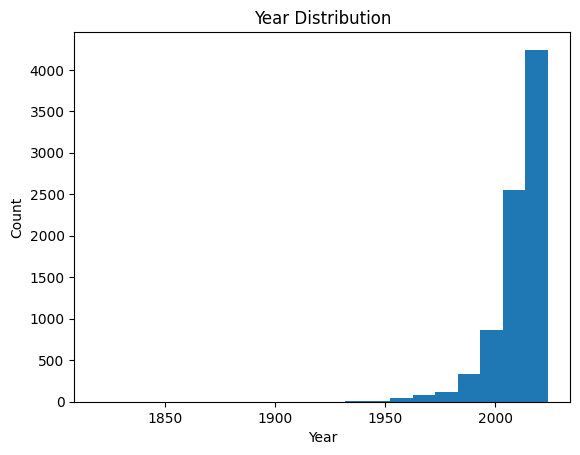

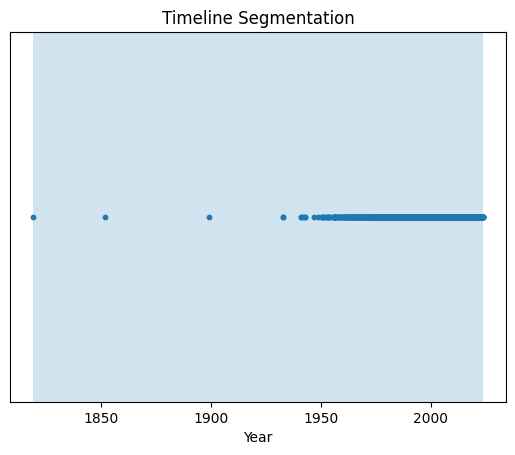


==== EVAL ====
Num segments: 1
Avg segment size: 8253.0
Min segment size: 8253
Max segment size: 8253


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
# =========================
# 1. LOAD DATA
# =========================
path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# =========================
# 2. BUILD DOCUMENTS
# =========================
BAD_WORDS = {
    "study", "approach", "method", "analysis",
    "system", "model", "paper", "result"
}

documents = []
for paper_id, paper in data.items():
    title = paper.get("title", "")
    
    keywords = [
        kw.lower() for kw in paper.get("keywords", [])
        if kw.lower() not in BAD_WORDS and len(kw) > 3
    ]
    
    content = f"{title}. {' '.join(keywords)}"
    
    documents.append({
        "id": paper_id,
        "content": content,
        "year": paper.get("pub_year"),
        "citations": paper.get("cited_by_count", 0)
    })

# remove missing year
documents = [d for d in documents if d["year"] is not None]

# =========================
# 3. SORT BY YEAR
# =========================
documents = sorted(documents, key=lambda x: x["year"])

texts = [d["content"] for d in documents]
years = np.array([d["year"] for d in documents])

print("Num docs:", len(documents))

# =========================
# 4. EMBEDDING
# =========================
model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(texts, show_progress_bar=True)

# =========================
# 5. PREFIX SUM (OPTIMIZE VARIANCE)
# =========================
# giúp tính variance O(1)

prefix_sum = np.cumsum(embeddings, axis=0)
prefix_sq_sum = np.cumsum(embeddings**2, axis=0)

def segment_variance(l, r):
    """
    compute variance of embeddings[l:r] (inclusive)
    """
    n = r - l + 1
    
    sum_vec = prefix_sum[r] - (prefix_sum[l-1] if l > 0 else 0)
    sq_sum_vec = prefix_sq_sum[r] - (prefix_sq_sum[l-1] if l > 0 else 0)
    
    mean = sum_vec / n
    var = np.sum(sq_sum_vec / n - mean**2)
    
    return var

# =========================
# 6. DP SEGMENTATION
# =========================
n = len(documents)

dp = np.full(n, np.inf)
split = np.full(n, -1)

penalty = 5.0  # tune this!!!

for i in tqdm(range(n), desc="DP Progress"):
    for j in range(i + 1):
        var = segment_variance(j, i)
        
        # time penalty
        time_span = years[i] - years[j]
        time_pen = 0.01 * time_span
        
        score = var + time_pen
        
        if j == 0:
            cost = score
        else:
            cost = dp[j-1] + score + penalty
        
        if cost < dp[i]:
            dp[i] = cost
            split[i] = j

# =========================
# 7. RECONSTRUCT SEGMENTS
# =========================
segments = []
i = n - 1

while i >= 0:
    j = split[i]
    segments.append((j, i))
    i = j - 1

segments.reverse()

print("\n==== SEGMENTS ====")
for (l, r) in segments:
    print(f"{years[l]} - {years[r]} | size={r-l+1}")

# =========================
# 8. VISUALIZATION 1: YEAR DISTRIBUTION
# =========================
plt.figure()
plt.hist(years, bins=20)
plt.title("Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# =========================
# 9. VISUALIZATION 2: TIMELINE SEGMENTS
# =========================
plt.figure()

# plot points
plt.scatter(years, np.zeros_like(years), s=10)

# plot segment boundaries
for (l, r) in segments:
    plt.axvspan(years[l], years[r], alpha=0.2)

plt.title("Timeline Segmentation")
plt.xlabel("Year")
plt.yticks([])
plt.show()

# =========================
# 10. EVALUATION (SIMPLE)
# =========================
segment_sizes = [r - l + 1 for (l, r) in segments]

print("\n==== EVAL ====")
print("Num segments:", len(segments))
print("Avg segment size:", np.mean(segment_sizes))
print("Min segment size:", np.min(segment_sizes))
print("Max segment size:", np.max(segment_sizes))

In [4]:
import numpy as np
import random
from collections import defaultdict

# =========================
# BUILD YEAR GROUP INDEX
# =========================
year_groups = defaultdict(list)

for i, doc in enumerate(documents):
    year_groups[doc["year"]].append(i)

year_list = sorted(year_groups.keys())

# =========================
# PICK 2 NEARBY YEARS
# =========================
idx = random.randint(0, len(year_list) - 2)

y1 = year_list[idx]
y2 = year_list[idx + 1]

idxs1 = year_groups[y1]
idxs2 = year_groups[y2]

print("\n==== DEBUG YEAR GROUPS ====")
print(f"Year 1: {y1} | #docs={len(idxs1)}")
print(f"Year 2: {y2} | #docs={len(idxs2)}")

# =========================
# HELPER: VARIANCE ON LIST OF INDICES
# =========================
def compute_group_variance(indices):
    embs = embeddings[indices]
    mean = embs.mean(axis=0)
    var = np.mean(np.linalg.norm(embs - mean, axis=1)**2)
    return var / embeddings.shape[1]  # normalize

def compute_time_pen(y_start, y_end):
    return 0.01 * (y_end - y_start)

# =========================
# CASE 1: NO SPLIT (MERGE 2 YEARS)
# =========================
merged_indices = idxs1 + idxs2

var_full = compute_group_variance(merged_indices)
time_full = compute_time_pen(y1, y2)

score_full = var_full + time_full

# =========================
# CASE 2: SPLIT
# =========================
var_1 = compute_group_variance(idxs1)
var_2 = compute_group_variance(idxs2)

time_1 = compute_time_pen(y1, y1)
time_2 = compute_time_pen(y2, y2)

var_split = var_1 + var_2
time_split = time_1 + time_2
penalty_split = penalty

score_split = var_split + time_split + penalty_split

# =========================
# PRINT RESULTS
# =========================
print("\n==== NO SPLIT (MERGED) ====")
print(f"Variance: {var_full:.6f}")
print(f"Time penalty: {time_full:.6f}")
print(f"Total score: {score_full:.6f}")

print("\n==== SPLIT (YEAR BY YEAR) ====")
print(f"Variance: {var_split:.6f}")
print(f"Time penalty: {time_split:.6f}")
print(f"Penalty: {penalty_split:.6f}")
print(f"Total score: {score_split:.6f}")

# =========================
# DECISION
# =========================
print("\n==== DECISION ====")
if score_split < score_full:
    print("→ SPLIT is better")
else:
    print("→ NO SPLIT is better")


==== DEBUG YEAR GROUPS ====
Year 1: 1947 | #docs=1
Year 2: 1949 | #docs=1

==== NO SPLIT (MERGED) ====
Variance: 0.000514
Time penalty: 0.020000
Total score: 0.020514

==== SPLIT (YEAR BY YEAR) ====
Variance: 0.000000
Time penalty: 0.000000
Penalty: 5.000000
Total score: 5.000000

==== DECISION ====
→ NO SPLIT is better


# DP with KL metric

In [5]:
import numpy as np
import pickle
from collections import Counter, defaultdict

# =========================
# INPUT: documents = [{"text": "...", "id": ...}, ...]
# =========================

docs = documents  # assume already loaded

# -------------------------
# 1. BUILD VOCAB
# -------------------------
vocab = set()
doc_tokens = []

for d in docs:
    tokens = d["content"].lower().split()
    doc_tokens.append(tokens)
    vocab.update(tokens)

vocab = sorted(list(vocab))
vocab_index = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

print("Vocab size:", V)

# -------------------------
# 2. PRECOMPUTE DOC TERM VECTORS (SPARSE COUNTS)
# -------------------------
doc_counts = []

for tokens in doc_tokens:
    c = Counter(tokens)
    doc_counts.append(c)

# -------------------------
# 3. SAVE ARTIFACTS
# -------------------------
with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

with open("vocab_index.pkl", "wb") as f:
    pickle.dump(vocab_index, f)

with open("doc_counts.pkl", "wb") as f:
    pickle.dump(doc_counts, f)

print("Saved: vocab, vocab_index, doc_counts")

Vocab size: 10256
Saved: vocab, vocab_index, doc_counts


In [10]:
import numpy as np
import pickle

# -------------------------
# LOAD ARTIFACTS
# -------------------------
with open("vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("vocab_index.pkl", "rb") as f:
    vocab_index = pickle.load(f)

with open("doc_counts.pkl", "rb") as f:
    doc_counts = pickle.load(f)

N = len(doc_counts)
V = len(vocab)

# -------------------------
# BUILD CUMULATIVE COUNTS (FAST RANGE QUERY)
# -------------------------
cum = [Counter()]

for c in doc_counts:
    new = cum[-1].copy()
    new.update(c)
    cum.append(new)

def get_segment_dist(l, r):
    """Return normalized BoW distribution for docs[l:r]"""
    counter = Counter()

    counter = cum[r] - cum[l]  # subtract Counters works partially

    total = sum(counter.values()) or 1
    vec = np.zeros(V)

    for w, c in counter.items():
        if w in vocab_index:
            vec[vocab_index[w]] = c / total

    return vec

# -------------------------
# KL DIVERGENCE
# -------------------------
def kl(P, Q, eps=1e-12):
    P = np.clip(P, eps, 1)
    Q = np.clip(Q, eps, 1)
    return np.sum(P * np.log(P / Q))

# -------------------------
# DP SEGMENTATION
# -------------------------
threshold = 0.05  # tune this
splits = [0]

i = 0
while i < N:
    best_j = None

    for j in range(i + 1, N):
        P = get_segment_dist(i, j)
        Q = get_segment_dist(j, min(j + (j - i), N))  # lookahead segment

        score = kl(P, Q)

        if score > threshold:
            best_j = j
            break

    if best_j is None:
        break

    splits.append(best_j)
    i = best_j

splits.append(N)

print("Splits:", splits)
print(len(splits))

Splits: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222

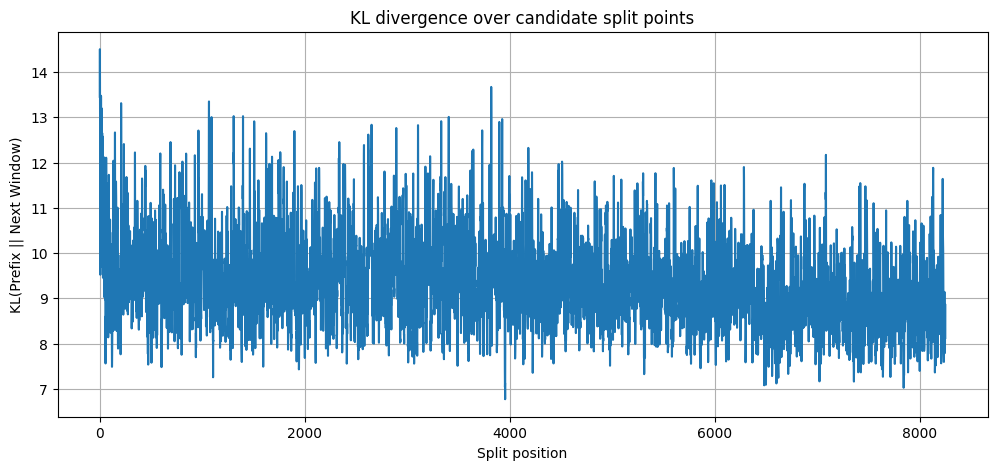

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -------------------------
# KL FUNCTION
# -------------------------
def kl(P, Q, eps=1e-12):
    P = np.clip(P, eps, 1)
    Q = np.clip(Q, eps, 1)
    return np.sum(P * np.log(P / Q))

# -------------------------
# SEGMENT DISTRIBUTION (reuse your cum)
# -------------------------
def get_segment_dist(l, r):
    counter = cum[r] - cum[l]

    vec = np.zeros(V)
    total = sum(counter.values()) or 1

    for w, c in counter.items():
        if w in vocab_index:
            vec[vocab_index[w]] = c / total

    return vec

# -------------------------
# FIXED WINDOW KL CURVE
# -------------------------
window = 5  # tune this (important)

ks = []
positions = []

for i in range(N - window):
    P = get_segment_dist(0, i + 1)
    Q = get_segment_dist(i + 1, min(i + 1 + window, N))

    score = kl(P, Q)

    ks.append(score)
    positions.append(i)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(12,5))
plt.plot(positions, ks)
plt.title("KL divergence over candidate split points")
plt.xlabel("Split position")
plt.ylabel("KL(Prefix || Next Window)")
plt.grid(True)
plt.show()

# DP with Bertopic

In [15]:
from bertopic import BERTopic
from collections import Counter, defaultdict
import numpy as np

# -------------------------
# HELPERS
# -------------------------
def normalize_topic_words(topic_words):
    words = [w for w, _ in topic_words]
    scores = np.array([s for _, s in topic_words])

    scores = scores + 1e-12
    probs = scores / scores.sum()

    return dict(zip(words, probs))


def get_topic_dist(topics):
    counter = Counter(topics)
    total = sum(counter.values())
    return {
        t: c / total
        for t, c in counter.items()
        if t != -1
    }


def build_word_dist(model, topic_dist):
    word_dist = defaultdict(float)

    for t, p_t in topic_dist.items():
        topic_words = model.get_topic(int(t))
        p_w_given_t = normalize_topic_words(topic_words)

        for w, p_w_t in p_w_given_t.items():
            word_dist[w] += p_t * p_w_t

    # normalize final distribution
    total = sum(word_dist.values()) + 1e-12
    for w in word_dist:
        word_dist[w] /= total

    return word_dist


def dict_to_vec(d, vocab=None):
    if vocab is None:
        vocab = sorted(d.keys())

    idx = {w: i for i, w in enumerate(vocab)}
    vec = np.zeros(len(vocab))

    for w, p in d.items():
        if w in idx:
            vec[idx[w]] = p

    return vec, vocab


def kl(P, Q, eps=1e-12):
    P = np.clip(P, eps, 1)
    Q = np.clip(Q, eps, 1)
    return np.sum(P * np.log(P / Q))


# -------------------------
# DATA SPLIT
# -------------------------
docs_2000 = [d["content"] for d in documents if d["year"] == 2000]
docs_2001 = [d["content"] for d in documents if d["year"] == 2001]

print("Docs 2000:", len(docs_2000))
print("Docs 2001:", len(docs_2001))

# -------------------------
# TRAIN BERTOPIC (SEPARATE)
# -------------------------
model_2000 = BERTopic(verbose=True)
topics_2000, _ = model_2000.fit_transform(docs_2000)

model_2001 = BERTopic(verbose=True)
topics_2001, _ = model_2001.fit_transform(docs_2001)

# -------------------------
# TOPIC INFO
# -------------------------
# print("\n===== TOPIC TABLE 2000 =====")
# print(model_2000.get_topic_info())

# print("\n===== TOPIC TABLE 2001 =====")
# print(model_2001.get_topic_info())

# -------------------------
# TOPIC DISTRIBUTION
# -------------------------
dist_2000_topic = get_topic_dist(topics_2000)
dist_2001_topic = get_topic_dist(topics_2001)

print("\n===== TOPIC DIST 2000 =====")
print(dist_2000_topic)

print("\n===== TOPIC DIST 2001 =====")
print(dist_2001_topic)

# -------------------------
# WORD DISTRIBUTION (YOUR MIXTURE MODEL)
# -------------------------
word_2000 = build_word_dist(model_2000, dist_2000_topic)
word_2001 = build_word_dist(model_2001, dist_2001_topic)

print("\n===== SAMPLE WORD DIST 2000 =====")
print(dict(list(word_2000.items())[:10]))

print("\n===== SAMPLE WORD DIST 2001 =====")
print(dict(list(word_2001.items())[:10]))

# -------------------------
# ALIGN VOCAB + KL
# -------------------------
vocab = sorted(set(word_2000.keys()) | set(word_2001.keys()))

P, vocab = dict_to_vec(word_2000, vocab)
Q, _ = dict_to_vec(word_2001, vocab)

score = kl(P, Q)

print("\n===== KL DIVERGENCE (2000 || 2001) =====")
print(score)

2026-03-28 15:46:33,769 - BERTopic - Embedding - Transforming documents to embeddings.


Docs 2000: 93
Docs 2001: 98


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

2026-03-28 15:46:37,199 - BERTopic - Embedding - Completed ✓
2026-03-28 15:46:37,199 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-28 15:46:37,258 - BERTopic - Dimensionality - Completed ✓
2026-03-28 15:46:37,259 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-28 15:46:37,262 - BERTopic - Cluster - Completed ✓
2026-03-28 15:46:37,263 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-28 15:46:37,269 - BERTopic - Representation - Completed ✓
2026-03-28 15:46:37,275 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-28 15:46:40,570 - BERTopic - Embedding - Completed ✓
2026-03-28 15:46:40,570 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-28 15:46:40,627 - BERTopic - Dimensionality - Completed ✓
2026-03-28 15:46:40,627 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-28 15:46:40,629 - BERTopic - Cluster - Completed ✓
2026-03-28 15:46:40,630 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-28 15:46:40,636 - BERTopic - Representation - Completed ✓



===== TOPIC DIST 2000 =====
{0: 0.6236559139784946, 1: 0.26881720430107525}

===== TOPIC DIST 2001 =====
{0: 0.23469387755102042, 2: 0.17346938775510204, 1: 0.19387755102040816}

===== SAMPLE WORD DIST 2000 =====
{'translation': 0.18254086000035585, 'machine': 0.1514294678693745, 'language': 0.11595836097361613, 'studies': 0.0653895362878627, 'computerassisted': 0.05305828983837447, 'science': 0.06663170547341132, 'computer': 0.039989247161239895, 'multimodal': 0.039360916109586926, 'and': 0.03578889360509125, 'natural': 0.057300050174110384}

===== SAMPLE WORD DIST 2001 =====
{'machine': 0.128363212570022, 'translation': 0.15055425904283565, 'computerassisted': 0.03312325735764436, 'language': 0.10239041873280345, 'science': 0.028427595839125453, 'statistical': 0.027901000595657467, 'decoding': 0.027069891777598467, 'computer': 0.02697640793737325, 'for': 0.025885716615408498, 'to': 0.023432199599033865}

===== KL DIVERGENCE (2000 || 2001) =====
1.3218789991543558


In [5]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from collections import Counter, defaultdict
from tqdm import tqdm
import numpy as np
import json
import random

# -------------------------
# REPRODUCIBILITY (IMPORTANT)
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -------------------------
# LOAD DATA
# -------------------------
with open(r"D:\timelline-generator\data\machine_translation_docs_info.json", "r", encoding="utf-8") as f:
    documents = json.load(f)

# -------------------------
# FIXED DATA SPLIT
# -------------------------
docs_2000 = [
    " ".join(d["keywords"])
    for d in documents.values()
    if d["pub_year"] == 2000
]

docs_2001 = [
    " ".join(d["keywords"])
    for d in documents.values()
    if d["pub_year"] == 2001
]

print("Docs 2000:", len(docs_2000))
print("Docs 2001:", len(docs_2001))

# -------------------------
# EMBEDDING MODEL (REDUCE RANDOMNESS)
# -------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------
# HELPERS
# -------------------------
def normalize_topic_words(topic_words):
    words = [w for w, _ in topic_words]
    scores = np.array([s for _, s in topic_words])

    scores = scores + 1e-12
    probs = scores / scores.sum()

    return dict(zip(words, probs))


def get_topic_dist(topics):
    counter = Counter(topics)
    total = sum(counter.values())
    return {
        t: c / total
        for t, c in counter.items()
        if t != -1
    }


def build_word_dist(model, topic_dist):
    word_dist = defaultdict(float)

    for t, p_t in topic_dist.items():
        topic_words = model.get_topic(int(t))
        if not topic_words:
            continue

        p_w_given_t = normalize_topic_words(topic_words)

        for w, p_w_t in p_w_given_t.items():
            word_dist[w] += p_t * p_w_t

    total = sum(word_dist.values()) + 1e-12
    for w in word_dist:
        word_dist[w] /= total

    return word_dist


def dict_to_vec(d, vocab=None):
    if vocab is None:
        vocab = sorted(d.keys())

    idx = {w: i for i, w in enumerate(vocab)}
    vec = np.zeros(len(vocab))

    for w, p in d.items():
        if w in idx:
            vec[idx[w]] = p

    return vec, vocab


def kl(P, Q, eps=1e-12):
    P = np.clip(P, eps, 1)
    Q = np.clip(Q, eps, 1)
    return np.sum(P * np.log(P / Q))


# -------------------------
# RUN EXPERIMENTS
# -------------------------
N_RUNS = 50
KL_scores = []

for i in tqdm(range(N_RUNS), desc="BERTopic KL stability"):

    # IMPORTANT: new models each run
    model_2000 = BERTopic(
        embedding_model=embedding_model,
        verbose=False
    )

    model_2001 = BERTopic(
        embedding_model=embedding_model,
        verbose=False
    )

    topics_2000, _ = model_2000.fit_transform(docs_2000)
    topics_2001, _ = model_2001.fit_transform(docs_2001)

    # topic distributions
    dist_2000_topic = get_topic_dist(topics_2000)
    dist_2001_topic = get_topic_dist(topics_2001)

    # word distributions (mixture model)
    word_2000 = build_word_dist(model_2000, dist_2000_topic)
    word_2001 = build_word_dist(model_2001, dist_2001_topic)

    # align vocab
    vocab = sorted(set(word_2000.keys()) | set(word_2001.keys()))

    P, _ = dict_to_vec(word_2000, vocab)
    Q, _ = dict_to_vec(word_2001, vocab)

    score = kl(P, Q)
    KL_scores.append(score)

# -------------------------
# STABILITY STATS
# -------------------------
KL_scores = np.array(KL_scores)

print("\n===== KL STABILITY ANALYSIS =====")
print(f"Runs     : {N_RUNS}")
print(f"Mean KL  : {KL_scores.mean():.4f}")
print(f"Std KL   : {KL_scores.std():.4f}")
print(f"Min KL   : {KL_scores.min():.4f}")
print(f"Max KL   : {KL_scores.max():.4f}")
print(f"Range    : {KL_scores.max() - KL_scores.min():.4f}")

Docs 2000: 93
Docs 2001: 98


BERTopic KL stability: 100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


===== KL STABILITY ANALYSIS =====
Runs     : 50
Mean KL  : 1.9155
Std KL   : 0.7011
Min KL   : 0.7032
Max KL   : 3.7786
Range    : 3.0754


In [6]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

from collections import Counter, defaultdict
from tqdm import tqdm
import numpy as np
import json
import random
import torch
import os

# -------------------------
# GLOBAL SEED CONTROL
# -------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

# deterministic torch (optional but useful)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------
# LOAD DATA
# -------------------------
with open(r"D:\timelline-generator\data\machine_translation_docs_info.json", "r", encoding="utf-8") as f:
    documents = json.load(f)

docs_2000 = [
    " ".join(d["keywords"])
    for d in documents.values()
    if d["pub_year"] == 2000
]

docs_2001 = [
    " ".join(d["keywords"])
    for d in documents.values()
    if d["pub_year"] == 2001
]

print("Docs 2000:", len(docs_2000))
print("Docs 2001:", len(docs_2001))

# -------------------------
# EMBEDDING MODEL
# -------------------------
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cpu"   # IMPORTANT: reduce GPU nondeterminism
)

# -------------------------
# HELPERS
# -------------------------
def normalize_topic_words(topic_words):
    words = [w for w, _ in topic_words]
    scores = np.array([s for _, s in topic_words])

    scores = scores + 1e-12
    probs = scores / scores.sum()

    return dict(zip(words, probs))


def get_topic_dist(topics):
    counter = Counter(topics)
    total = sum(counter.values())
    return {t: c / total for t, c in counter.items() if t != -1}


def build_word_dist(model, topic_dist):
    word_dist = defaultdict(float)

    for t, p_t in topic_dist.items():
        topic_words = model.get_topic(int(t))
        if not topic_words:
            continue

        p_w_given_t = normalize_topic_words(topic_words)

        for w, p_w_t in p_w_given_t.items():
            word_dist[w] += p_t * p_w_t

    total = sum(word_dist.values()) + 1e-12
    for w in word_dist:
        word_dist[w] /= total

    return word_dist


def dict_to_vec(d, vocab=None):
    if vocab is None:
        vocab = sorted(d.keys())

    idx = {w: i for i, w in enumerate(vocab)}
    vec = np.zeros(len(vocab))

    for w, p in d.items():
        if w in idx:
            vec[idx[w]] = p

    return vec, vocab


def kl(P, Q, eps=1e-12):
    P = np.clip(P, eps, 1)
    Q = np.clip(Q, eps, 1)
    return np.sum(P * np.log(P / Q))


# -------------------------
# DETECTION MODELS (FULLY FIXED PIPELINE)
# -------------------------

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine",
    random_state=SEED
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    prediction_data=True,
    core_dist_n_jobs=1
)

# -------------------------
# RUN EXPERIMENTS
# -------------------------
N_RUNS = 50
KL_scores = []

for i in tqdm(range(N_RUNS), desc="Deterministic BERTopic KL"):

    model_2000 = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        verbose=False
    )

    model_2001 = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        verbose=False
    )

    topics_2000, _ = model_2000.fit_transform(docs_2000)
    topics_2001, _ = model_2001.fit_transform(docs_2001)

    dist_2000_topic = get_topic_dist(topics_2000)
    dist_2001_topic = get_topic_dist(topics_2001)

    word_2000 = build_word_dist(model_2000, dist_2000_topic)
    word_2001 = build_word_dist(model_2001, dist_2001_topic)

    vocab = sorted(set(word_2000.keys()) | set(word_2001.keys()))

    P, _ = dict_to_vec(word_2000, vocab)
    Q, _ = dict_to_vec(word_2001, vocab)

    KL_scores.append(kl(P, Q))

# -------------------------
# RESULTS
# -------------------------
KL_scores = np.array(KL_scores)

print("\n===== DETERMINISTIC KL ANALYSIS =====")
print(f"Runs     : {N_RUNS}")
print(f"Mean KL  : {KL_scores.mean():.4f}")
print(f"Std KL   : {KL_scores.std():.4f}")
print(f"Min KL   : {KL_scores.min():.4f}")
print(f"Max KL   : {KL_scores.max():.4f}")
print(f"Range    : {KL_scores.max() - KL_scores.min():.4f}")

Docs 2000: 93
Docs 2001: 98


Deterministic BERTopic KL: 100%|██████████| 50/50 [00:48<00:00,  1.04it/s]


===== DETERMINISTIC KL ANALYSIS =====
Runs     : 50
Mean KL  : 2.9986
Std KL   : 0.0000
Min KL   : 2.9986
Max KL   : 2.9986
Range    : 0.0000


In [ ]:
from fn.pipeline import build_timeline
from fn.metrics_extended import compute_total_score

result = build_timeline(
    r"D:\timelline-generator\data\machine_translation_docs_info.json",
    lambda_penalty=0.5
)

segments = result["segments"]
year_data = result["year_distributions"]
years = result["sorted_years"]

total_score, breakdown = compute_total_score(
    year_data,
    segments,
    lambda_penalty=0.1
)

result["total_score"] = total_score
result["score_breakdown"] = breakdown

100%|██████████| 84/84 [00:00<00:00, 6095.21it/s]


In [28]:
from fn.pipeline import build_timeline
from fn.metrics_extended import compute_total_score

path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

best_result = None
best_lambda = None
best_score = float("inf")

all_results = []

for i in range(11):
    lambda_penalty = i / 10

    result = build_timeline(
        path,
        lambda_penalty=lambda_penalty
    )

    segments = result["segments"]
    year_data = result["year_distributions"]

    total_score, breakdown = compute_total_score(
        year_data,
        segments,
    )

    result["total_score"] = total_score
    result["score_breakdown"] = breakdown
    result["lambda"] = lambda_penalty

    all_results.append(result)

    print(f"lambda={lambda_penalty:.1f} | score={total_score:.6f} | segments={len(segments)}")

    if total_score < best_score:
        best_score = total_score
        best_lambda = lambda_penalty
        best_result = result

print("\nBEST RESULT")
print("lambda:", best_lambda)
print("score:", best_score)
print("segments:", len(best_result["segments"]))

100%|██████████| 84/84 [00:00<00:00, 5916.99it/s]


lambda=0.0 | score=8.400000 | segments=84


100%|██████████| 84/84 [00:00<00:00, 4246.22it/s]


lambda=0.1 | score=8.202011 | segments=73


100%|██████████| 84/84 [00:00<00:00, 5759.90it/s]


...

lambda=0.8 | score=19.834152 | segments=4


100%|██████████| 84/84 [00:00<00:00, 5724.43it/s]


lambda=0.9 | score=20.558936 | segments=3


100%|██████████| 84/84 [00:00<00:00, 5861.28it/s]


lambda=1.0 | score=21.455040 | segments=2

BEST RESULT
lambda: 0.1
score: 8.20201067553037
segments: 73


In [4]:
import importlib
import fn.metrics as metrics_mod
import fn.pipeline as pipeline_mod

# Force reload to avoid using stale functions cached in notebook kernel
importlib.reload(metrics_mod)
importlib.reload(pipeline_mod)
build_timeline = pipeline_mod.build_timeline

path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

best_result = None
best_lambda = None
# Vì build_timeline trả về Loss (càng thấp càng tốt)
best_loss = float("inf")

all_results = []

for i in range(11):
    lambda_val = i / 10.0

    # Pipeline đã tự tính toán segments và total_score (loss) bên trong
    result = build_timeline(
        path,
        lambda_penalty=lambda_val
    )

    # Lấy thông tin đã có sẵn trong result
    current_loss = result["total_score"]
    segments = result["segments"]

    # Gán thêm lambda vào kết quả để tiện theo dõi
    result["lambda"] = lambda_val
    all_results.append(result)

    print(f"lambda={lambda_val:.1f} | loss={current_loss:.6f} | segments={len(segments)}")

    # So sánh để tìm config tốt nhất
    if current_loss < best_loss:
        best_loss = current_loss
        best_lambda = lambda_val
        best_result = result

print("\n" + "=" * 30)
print("KẾT QUẢ TỐI ƯU NHẤT")
print(f"Lambda: {best_lambda}")
print(f"Loss thấp nhất: {best_loss:.6f}")
print(f"Số lượng đoạn: {len(best_result['segments'])}")
# In chi tiết các năm được chia
for b in best_result["score_breakdown"]:
    print(f"  - Đoạn {b['range']}: (Độ dài: {b['length']} năm)")
print("=" * 30)

100%|██████████| 84/84 [00:00<00:00, 3062.52it/s]


lambda=0.0 | loss=4.200000 | segments=84


100%|██████████| 84/84 [00:00<00:00, 4146.37it/s]


lambda=0.1 | loss=316.777537 | segments=73


100%|██████████| 84/84 [00:00<00:00, 4352.82it/s]


...

lambda=0.8 | loss=1025.827926 | segments=4


100%|██████████| 84/84 [00:00<00:00, 5355.65it/s]


lambda=0.9 | loss=1045.145571 | segments=3


100%|██████████| 84/84 [00:00<00:00, 3532.12it/s]


lambda=1.0 | loss=1047.026118 | segments=2

KẾT QUẢ TỐI ƯU NHẤT
Lambda: 0.0
Loss thấp nhất: 4.200000
Số lượng đoạn: 84
  - Đoạn (0, 0): (Độ dài: 1 năm)
  - Đoạn (1, 1): (Độ dài: 1 năm)
  - Đoạn (2, 2): (Độ dài: 1 năm)
  - Đoạn (3, 3): (Độ dài: 1 năm)
  - Đoạn (4, 4): (Độ dài: 1 năm)
  - Đoạn (5, 5): (Độ dài: 1 năm)
  - Đoạn (6, 6): (Độ dài: 1 năm)
  - Đoạn (7, 7): (Độ dài: 1 năm)
  - Đoạn (8, 8): (Độ dài: 1 năm)
  - Đoạn (9, 9): (Độ dài: 1 năm)
  - Đoạn (10, 10): (Độ dài: 1 năm)
  - Đoạn (11, 11): (Độ dài: 1 năm)
  - Đoạn (12, 12): (Độ dài: 1 năm)
  - Đoạn (13, 13): (Độ dài: 1 năm)
  - Đoạn (14, 14): (Độ dài: 1 năm)
  - Đoạn (15, 15): (Độ dài: 1 năm)
  - Đoạn (16, 16): (Độ dài: 1 năm)
  - Đoạn (17, 17): (Độ dài: 1 năm)
  - Đoạn (18, 18): (Độ dài: 1 năm)
  - Đoạn (19, 19): (Độ dài: 1 năm)
  - Đoạn (20, 20): (Độ dài: 1 năm)
  - Đoạn (21, 21): (Độ dài: 1 năm)
  - Đoạn (22, 22): (Độ dài: 1 năm)
  - Đoạn (23, 23): (Độ dài: 1 năm)
  - Đoạn (24, 24): (Độ dài: 1 năm)
  - Đoạn (25, 25): (Độ dài

100%|██████████| 84/84 [00:00<00:00, 4948.27it/s]


lambda=0.00 | k=84 | distortion=0.000000


100%|██████████| 84/84 [00:00<00:00, 5245.85it/s]


lambda=0.05 | k=84 | distortion=0.000000


100%|██████████| 84/84 [00:00<00:00, 5887.63it/s]


...

lambda=0.90 | k=3 | distortion=1044.995571


100%|██████████| 84/84 [00:00<00:00, 3192.24it/s]


lambda=0.95 | k=3 | distortion=1044.995571


100%|██████████| 84/84 [00:00<00:00, 4077.32it/s]


lambda=1.00 | k=2 | distortion=1046.926118


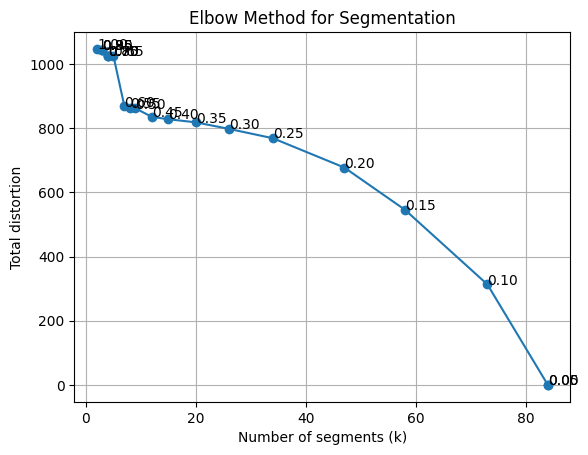

In [5]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import fn.metrics as metrics_mod
import fn.pipeline as pipeline_mod

# reload
importlib.reload(metrics_mod)
importlib.reload(pipeline_mod)

build_timeline = pipeline_mod.build_timeline

path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

lambdas = np.arange(0, 1.01, 0.05)

all_k = []
all_distortion = []

for lam in lambdas:
    result = build_timeline(
        path,
        lambda_penalty=lam
    )

    segments = result["segments"]
    breakdown = result["score_breakdown"]

    # chỉ lấy distortion (KHÔNG dùng total_score)
    total_distortion = sum(b["distortion"] for b in breakdown)

    k = len(segments)

    all_k.append(k)
    all_distortion.append(total_distortion)

    print(f"lambda={lam:.2f} | k={k} | distortion={total_distortion:.6f}")

# ===== VẼ ELBOW =====
plt.figure()
plt.plot(all_k, all_distortion, marker='o')
plt.xlabel("Number of segments (k)")
plt.ylabel("Total distortion")
plt.title("Elbow Method for Segmentation")
plt.grid()

# nếu muốn nhìn rõ thứ tự λ:
for i, lam in enumerate(lambdas):
    plt.annotate(f"{lam:.2f}", (all_k[i], all_distortion[i]))

plt.show()

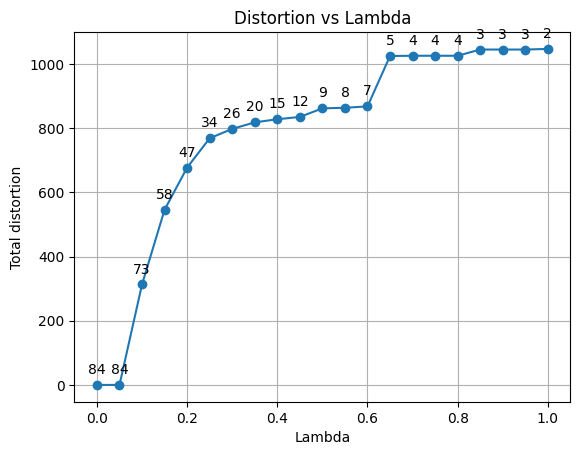

In [7]:
import matplotlib.pyplot as plt

plt.figure()

# plot theo lambda
plt.plot(lambdas, all_distortion, marker='o')

plt.xlabel("Lambda")
plt.ylabel("Total distortion")
plt.title("Distortion vs Lambda")
plt.grid()

# annotate mỗi điểm bằng số segment (k)
for i in range(len(lambdas)):
    plt.annotate(
        f"{all_k[i]}",
        (lambdas[i], all_distortion[i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

plt.show()

In [1]:
import matplotlib.pyplot as plt
from fn.pipeline import *
path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

result = build_timeline(
    path,
    lambda_penalty=0.3
)

segments = result["segments"]
years = result["sorted_years"]



100%|██████████| 84/84 [00:00<00:00, 6032.70it/s]


In [2]:
import pandas as pd

segments = result["segments"]
years = result["sorted_years"]
year_data = result["year_distributions"]

rows = []

for (l, r) in segments:
    start_year = years[l]
    end_year = years[r]

    total_docs = sum(
        len(year_data[i].get("docs", []))
        for i in range(l, r+1)
    )

    rows.append({
        "start": start_year,
        "end": end_year,
        "length": r - l + 1,
        "total_docs": total_docs
    })

df = pd.DataFrame(rows)
df

,start,end,length,total_docs
0,1819,1819,1,1
1,1852,1852,1,1
2,1899,1899,1,1
3,1933,1933,1,2
4,1941,1941,1,2
5,1942,1942,1,1
6,1943,1943,1,2
7,1947,1947,1,1
8,1949,1949,1,1
9,1950,1951,2,4


In [ ]:
def get_segment_theme(year_distributions, l, r, top_k=5):
    seg_dists = [
        year_distributions[i]["dist"]
        for i in range(l, r + 1)
    ]

    weights = [
        len(year_distributions[i].get("docs", [])) or 1
        for i in range(l, r + 1)
    ]

    total_weight = sum(weights)

    bary = {}
    for dist, w in zip(seg_dists, weights):
        for k, v in dist.items():
            bary[k] = bary.get(k, 0) + w * v

    for k in bary:
        bary[k] /= total_weight

    return sorted(bary.items(), key=lambda x: x[1], reverse=True)[:top_k]

segments = result["segments"]
years = result["sorted_years"]
year_data = result["year_distributions"]

for (l, r) in segments:
    start = years[l]
    end = years[r]

    theme = get_segment_theme(year_data, l, r)

    print(f"\n[{start}-{end}]")
    print(", ".join([f"{k}:{v:.2f}" for k, v in theme]))


[1819-1819]
technology:0.11, mechanical engineering:0.11, abstract machine:0.11, machine translation:0.11, algorithmic development:0.11

[1852-1852]
machine-readable dictionary:0.06, text mining:0.06, creative writing:0.06, turing machine:0.06, machine-readable representation:0.06

[1899-1899]
english:0.05, linguistics:0.05, grammatical formalism:0.05, grammar:0.05, spoken language technology:0.05

[1933-1933]
linguistics:0.08, specialized translation:0.08, machine translation:0.08, language:0.08, translation studies:0.08

[1941-1941]
machine intelligence:0.06, human-computer interaction:0.06, human performance:0.06, mechanical engineering:0.06, machine translation:0.06

[1942-1942]
corpus linguistics:0.07, linguistics:0.07, language technology:0.07, applied linguistics:0.07, language model:0.07

[1943-1943]
machine translation:0.08, human robot interaction:0.04, technology:0.04, philosophy of computer science:0.04, artificial intelligence:0.04

[1947-1947]
linguistics:0.05, indigenou

# Add more data to JS

## Machine Translation

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
100%|██████████| 84/84 [00:00<00:00, 4100.67it/s]


lambda=0.00 | k=84 | distortion=-0.000010


100%|██████████| 84/84 [00:00<00:00, 3873.58it/s]


lambda=0.05 | k=82 | distortion=54.416756


100%|██████████| 84/84 [00:00<00:00, 3918.43it/s]


...

lambda=0.90 | k=2 | distortion=844.384082


100%|██████████| 84/84 [00:00<00:00, 4250.83it/s]


lambda=0.95 | k=2 | distortion=844.384082


100%|██████████| 84/84 [00:00<00:00, 3723.97it/s]


lambda=1.00 | k=2 | distortion=844.384082


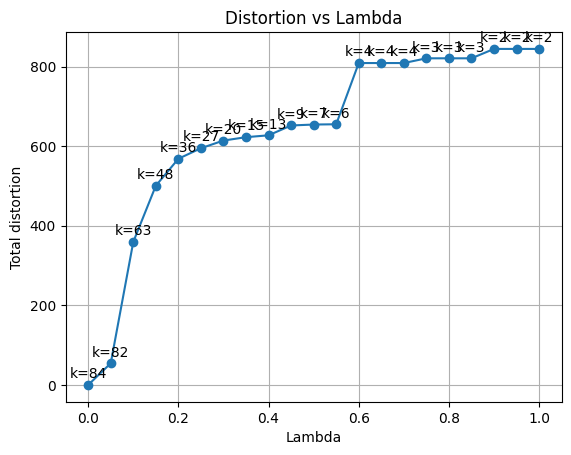

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import fn.metrics as metrics_mod
import fn.pipeline as pipeline_mod

# reload
importlib.reload(metrics_mod)
importlib.reload(pipeline_mod)

build_timeline = pipeline_mod.build_timeline

path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

lambdas = np.arange(0, 1.01, 0.05)

all_k = []
all_distortion = []

for lam in lambdas:
    result = build_timeline(
        path,
        lambda_penalty=lam
    )

    segments = result["segments"]
    breakdown = result["score_breakdown"]

    total_distortion = sum(b["distortion"] for b in breakdown)
    k = len(segments)

    all_k.append(k)
    all_distortion.append(total_distortion)

    print(f"lambda={lam:.2f} | k={k} | distortion={total_distortion:.6f}")

# ===== VẼ =====
plt.figure()

# X = lambda, Y = distortion
plt.plot(lambdas, all_distortion, marker='o')

plt.xlabel("Lambda")
plt.ylabel("Total distortion")
plt.title("Distortion vs Lambda")
plt.grid()

# annotate: ghi k tại mỗi điểm
for i, lam in enumerate(lambdas):
    plt.annotate(
        f"k={all_k[i]}",
        (lambdas[i], all_distortion[i]),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center'
    )

plt.show()

In [ ]:
import pandas as pd
import numpy as np

lam = 0.3
result = build_timeline(path, lambda_penalty=lam)

segments = result["segments"]
year_data = result["year_distributions"]
years = result["sorted_years"]

rows = []

for (l, r) in segments:
    seg_years = years[l:r+1]

    # ===== số doc trong period =====
    num_docs = sum(
        len(year_data[i]["docs"])
        for i in range(l, r + 1)
    )

    # ===== barycenter keyword =====
    bary = {}
    for i in range(l, r + 1):
        dist = year_data[i]["dist"]
        for k, v in dist.items():
            bary[k] = bary.get(k, 0) + v

    total = sum(bary.values()) + 1e-12
    bary = {k: v / total for k, v in bary.items()}

    top_keywords = sorted(bary.items(), key=lambda x: -x[1])[:10]

    rows.append({
        "from_year": seg_years[0],
        "to_year": seg_years[-1],
        "length_years": len(seg_years),
        "num_docs": num_docs,
        "top_keywords": top_keywords
    })

df = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df[["from_year", "to_year", "num_docs"]]

100%|██████████| 84/84 [00:00<00:00, 2343.92it/s]


,from_year,to_year,length_years,num_docs,top_keywords
0,1819,1852,2,2,"[(machine translation, 0.08496732026139542), (computer science, 0.08496732026139542), (machine learning, 0.08496732026139542), (technology, 0.05555555555552777), (mechanical engineering, 0.05555555555552777), (abstract machine, 0.05555555555552777), (algorithmic development, 0.05555555555552777), (composition des machines, 0.05555555555552777), (automation, 0.05555555555552777), (machine-readable dictionary, 0.029411764705867646)]"
1,1899,1933,2,3,"[(linguistics, 0.06631578947365106), (machine translation, 0.06631578947365106), (language, 0.06631578947365106), (computational linguistics, 0.04631578947366105), (applied linguistics, 0.04631578947366105), (specialized translation, 0.039999999999979996), (translation studies, 0.039999999999979996), (english, 0.02631578947367105), (grammatical formalism, 0.02631578947367105), (grammar, 0.02631578947367105)]"
2,1941,1941,1,2,"[(machine intelligence, 0.05555555555549999), (human-computer interaction, 0.05555555555549999), (human performance, 0.05555555555549999), (mechanical engineering, 0.05555555555549999), (machine translation, 0.05555555555549999), (man-machine interface, 0.05555555555549999), (technology, 0.05555555555549999), (wearable technology, 0.05555555555549999), (intelligent robotic system, 0.05555555555549999), (human-machine interaction, 0.05555555555549999)]"
3,1942,1942,1,1,"[(corpus linguistics, 0.0714285714285), (linguistics, 0.0714285714285), (language technology, 0.0714285714285), (applied linguistics, 0.0714285714285), (language model, 0.0714285714285), (computational semantics, 0.0714285714285), (computational linguistics, 0.0714285714285), (speech processing, 0.0714285714285), (spoken language processing, 0.0714285714285), (natural language processing, 0.0714285714285)]"
4,1943,1943,1,2,"[(machine translation, 0.08333333333324999), (human robot interaction, 0.041666666666624996), (technology, 0.041666666666624996), (philosophy of computer science, 0.041666666666624996), (artificial intelligence, 0.041666666666624996), (mechanical engineering, 0.041666666666624996), (abstract machine, 0.041666666666624996), (autonomous robot, 0.041666666666624996), (human machine system, 0.041666666666624996), (machine intelligence, 0.041666666666624996)]"
5,1947,1947,1,1,"[(linguistics, 0.047619047618999995), (indigenous language, 0.047619047618999995), (language documentation, 0.047619047618999995), (specialized translation, 0.047619047618999995), (historical linguistics, 0.047619047618999995), (special reference, 0.047619047618999995), (general linguistics, 0.047619047618999995), (indigenous study, 0.047619047618999995), (anthropology, 0.047619047618999995), (machine translation, 0.047619047618999995)]"
6,1949,1949,1,1,"[(systems modeling, 0.142857142857), (systems engineering, 0.142857142857), (machine translation, 0.142857142857), (curve fitting, 0.142857142857), (systems biology, 0.142857142857), (frequency curves, 0.142857142857), (translation studies, 0.142857142857)]"
7,1950,1951,2,4,"[(language, 0.09920634920629959), (machine translation, 0.09920634920629959), (linguistics, 0.07539682539678769), (translation studies, 0.0714285714285357), (english, 0.051587301587275786), (language adaptation, 0.051587301587275786), (specialized translation, 0.0476190476190238), (computer-assisted translation, 0.0476190476190238), (applied linguistics, 0.027777777777763885), (language science, 0.027777777777763885)]"
8,1952,1952,1,1,"[(corpus linguistics, 0.0666666666666), (real-time protocol, 0.0666666666666), (unmanned aerial vehicle, 0.0666666666666), (wireless communication, 0.0666666666666), (data science, 0.0666666666666), (performance evaluation, 0.0666666666666), (machine translation, 0.0666666666666), (computer science, 0.0666666666666), (computer security, 0.0666666666666), (communication, 0.0666666666666)]"
9,1953,1955,3,6,"[(machine translation, 0.07850279801496696), (language, 0.055221201562646566), (spe

In [8]:
import pandas as pd
import numpy as np

lam = 0.35
result = build_timeline(path, lambda_penalty=lam)

segments = result["segments"]
year_data = result["year_distributions"]
years = result["sorted_years"]

rows = []

for (l, r) in segments:
    seg_years = years[l:r+1]

    # ===== số doc trong period =====
    num_docs = sum(
        len(year_data[i]["docs"])
        for i in range(l, r + 1)
    )

    # ===== barycenter keyword =====
    bary = {}
    for i in range(l, r + 1):
        dist = year_data[i]["dist"]
        for k, v in dist.items():
            bary[k] = bary.get(k, 0) + v

    total = sum(bary.values()) + 1e-12
    bary = {k: v / total for k, v in bary.items()}

    top_keywords = sorted(bary.items(), key=lambda x: -x[1])[:10]

    rows.append({
        "from_year": seg_years[0],
        "to_year": seg_years[-1],
        "length_years": len(seg_years),
        "num_docs": num_docs,
        "top_keywords": top_keywords
    })

df = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df[["from_year", "to_year", "num_docs"]]

100%|██████████| 84/84 [00:00<00:00, 3647.60it/s]


,from_year,to_year,num_docs
0,1819,1852,2
1,1899,1933,3
2,1941,1942,3
3,1943,1947,3
4,1949,1949,1
5,1950,1951,4
6,1952,1952,1
7,1953,1955,6
8,1956,1959,18
9,1960,1968,59


## Machine Learning

Scanning lambda:   5%|▍         | 1/21 [46:48<15:36:04, 2808.23s/it]

lambda=0.00 | k=136 | distortion=0.000068


Scanning lambda:  10%|▉         | 2/21 [1:24:54<13:12:01, 2501.15s/it]

lambda=0.05 | k=136 | distortion=0.000068


Scanning lambda:  14%|█▍        | 3/21 [2:04:06<12:09:57, 2433.18s/it]

...

lambda=0.90 | k=5 | distortion=4663.493045


Scanning lambda:  95%|█████████▌| 20/21 [15:17:16<55:30, 3330.76s/it]  

lambda=0.95 | k=4 | distortion=4686.321824


Scanning lambda: 100%|██████████| 21/21 [16:15:31<00:00, 2787.23s/it]

lambda=1.00 | k=4 | distortion=4686.321824


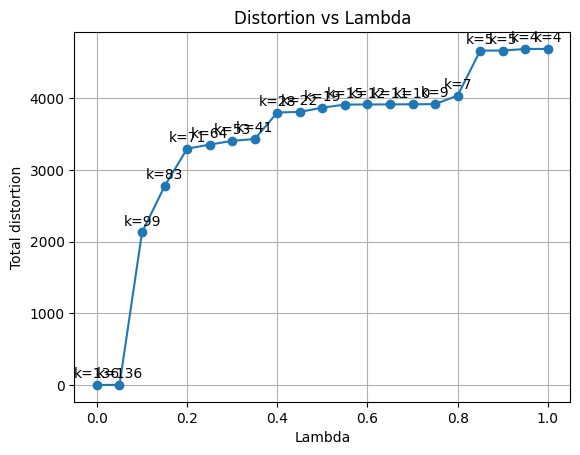

In [9]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import fn.metrics as metrics_mod
import fn.pipeline as pipeline_mod

# reload
importlib.reload(metrics_mod)
importlib.reload(pipeline_mod)

build_timeline = pipeline_mod.build_timeline

# ===== đổi path =====
path = r"D:\timelline-generator\data\machine_learning_docs_info.json"

lambdas = np.arange(0, 1.01, 0.05)

all_k = []
all_distortion = []

# ===== thêm tqdm =====
for lam in tqdm(lambdas, desc="Scanning lambda"):
    result = build_timeline(
        path,
        lambda_penalty=lam
    )

    segments = result["segments"]
    breakdown = result["score_breakdown"]

    total_distortion = sum(b["distortion"] for b in breakdown)
    k = len(segments)

    all_k.append(k)
    all_distortion.append(total_distortion)

    print(f"lambda={lam:.2f} | k={k} | distortion={total_distortion:.6f}")

# ===== VẼ =====
plt.figure()

plt.plot(lambdas, all_distortion, marker='o')

plt.xlabel("Lambda")
plt.ylabel("Total distortion")
plt.title("Distortion vs Lambda")
plt.grid()

# annotate: ghi k tại mỗi điểm
for i, lam in enumerate(lambdas):
    plt.annotate(
        f"k={all_k[i]}",
        (lambdas[i], all_distortion[i]),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center'
    )

plt.show()

In [ ]:
x